## Markov Chain Monte Carlo (MCMC)
### 2026/03/05

### Section 1 - Intro

Markov Chain Monte Carlo (MCMC) is a sampling method used to efficiently map out a probability distribution, weighted towards the greatest probability.
The Markov chain is formed by the following rules:

1. If $f(x') > f(x)$ : accept
2. If $f(x') < f(x)$ : accept with probabilty $\frac{f(x')}{f(x)}$

These rules effectively mean we:

1. Sample the high density regions
2. Sometimes sample the low density regions

In python we can use the package `emcee` to perform this. In this notebook I will test `emcee` against a polynomial function.

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters, Minimizer, create_params, report_fit, conf_interval, printfuncs
import emcee
import corner
import pandas
import tqdm

Lets define our underlying test data is a noisy sine wave. 
The task is to find the parameters that best fit this data. Since our test data resembles a sine wave, I will choose my model to be a sine function $y_{model} = a\mathrm{sin}(2\pi x/p)$, with two parameters a (amplitude), and p (period) - the test data is also this but with added noise.

For my application, the noisy test data is my experimental data, the model is my synthetic data.

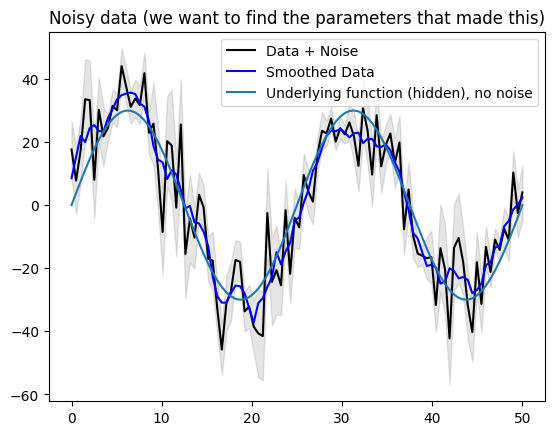

In [102]:
np.random.seed(0)

def testdata(x, a, p, noise = True):
    if noise:
        return a * np.sin(2*np.pi*x/p) + np.random.normal(size=len(x), scale=10)
    else:
        return a * np.sin(2*np.pi*x/p)

a = 30
p = 25
xdata = np.linspace(0, 50, 100)
ydata = testdata(xdata, a, p)
ydata_clean = testdata(xdata, a, p, noise=False)

# Standard deviation of each point using mean of local variance around point
# smooth the data using median filter with a window size of 5 points
window = 5
ydata_smooth = np.convolve(ydata, np.ones(window)/window, mode='same')
# fractional residuals of each point with smoothed data
frac_var = (ydata - ydata_smooth)**2
# variance of point is mean of frac_var within window times by the value of that point
std2 = np.convolve(frac_var, np.ones(window), mode='same')
count = np.convolve(np.ones_like(ydata), np.ones(window), mode='same')#
count = np.maximum(count,2.)
std = np.sqrt(std2/(count-1))

plt.title("Noisy data (we want to find the parameters that made this)")
plt.plot(xdata, ydata, label="Data + Noise", color="black")
plt.plot(xdata, ydata_smooth, label="Smoothed Data", color="blue")
plt.plot(xdata, ydata_clean, label="Underlying function (hidden), no noise")
plt.fill_between(xdata,ydata-std,ydata+std, color="black", alpha=0.1)
plt.legend()

I define my model (my synthetic data) as:

$$f(x,a,p) = a\ \mathrm{sin}(2 \pi x/p)$$

The fitting procedure I will use is a reduced chi-squared:

$$\chi^2 = \frac{1}{N-M} \Sigma^n_{n=0}\frac{(y_i - y_m(a,p))^2}{\sigma^2}$$

Note my noisy test data does not have a standard deviation $\sigma$ associated with it, though I could define one based on the local variance..

In [103]:
def residual(params, xdata, ydata, ysigma, just_generative=False):
    amp = params["amp"]
    period = params["period"]
    y_model = amp * np.sin(2*np.pi*xdata/period)
    return (y_model - ydata) / ysigma

def lnprob(params, xdata, ydata, ysigma):
    amp = params["amp"]
    period = params["period"]
    y_model = amp * np.sin(2*np.pi*xdata/period)
    return -0.5 * np.sum(((y_model - ydata) / ysigma)**2 + np.log(2 * np.pi * ysigma**2))

The objective function is formed of the possible $\chi^2$ values for my parameter space. It should have some minima or maxima since one set of parameters $a$ and $p$ should fit my noisy data the best. The objective function is effectively the probability distribution that we want to find using MCMC.

In [104]:
# params = Parameters()
params = create_params(amp=dict(value=40, min=1, max=50), 
                       period=dict(value=33, min=1, max=50))

### `LMFIT` + `emcee` Markov Chain Monte Carlo

100%|██████████| 200/200 [00:00<00:00, 208.85it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 4;
tau: [24.66746845 23.7898717 ]
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 20000
    # data points      = 1
    # variables        = 2
    chi-square         = 136383.720
    reduced chi-square = 136383.720
    Akaike info crit   = 15.8232277
    Bayesian info crit = 11.8232277
[[Variables]]
    amp:     28.7613230 +/- 1.27346865 (4.43%) (init = 40)
    period:  24.7359236 +/- 0.13621728 (0.55%) (init = 33)
[[Correlations]] (unreported correlations are < 0.100)
    C(amp, period) = -0.7681


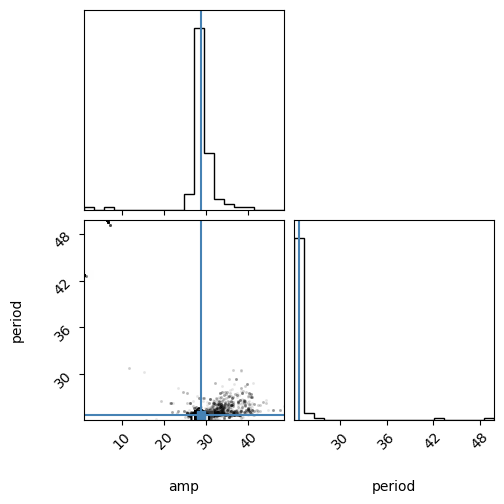

In [105]:
mcmc_minimizer = Minimizer(lnprob, params, fcn_args=(xdata, ydata, std))
mcmc_result = mcmc_minimizer.emcee(steps=200, burn = 50, reuse_sampler=False, float_behavior="posterior")

# compute the fitted model from the best-fit parameters
best_a = mcmc_result.params['amp'].value
best_p = mcmc_result.params['period'].value
fitted_model = best_a * np.sin(2*np.pi*xdata/best_p)

# show the minimization result
report_fit(mcmc_result)
emcee_plot = corner.corner(mcmc_result.flatchain, labels=mcmc_result.var_names,
                           truths=list(mcmc_result.params.valuesdict().values()))

In [106]:
samples = mcmc_result.flatchain
for param in params:
    result = mcmc_result.params[param].value
    stderr = mcmc_result.params[param].stderr
    print(f"{param}: {result:.2f} +/- {stderr:.2f}")
    lower_bound = result - stderr
    upper_bound = result + stderr
    samples_filtered = samples[(samples[param] > lower_bound) & (samples[param] < upper_bound)]

amp: 28.76 +/- 1.27
period: 24.74 +/- 0.14


In [107]:
y_models = []
for i, row in samples_filtered.iterrows():
    y_model_i = row["amp"] * np.sin(2*np.pi*xdata/row["period"])
    y_models.append(y_model_i)
y_models = np.array(y_models)

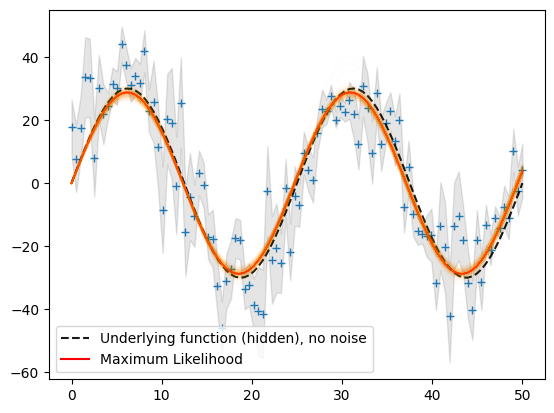

In [108]:
#Plot
y_model = best_a * np.sin(2*np.pi*xdata/best_p)
plt.plot(xdata, ydata, '+', )
plt.plot(xdata, ydata_clean, label="Underlying function (hidden), no noise", color="black", ls="--", alpha=0.9)
plt.plot(xdata, y_model, label="Maximum Likelihood", color="red")
plt.fill_between(xdata,ydata-std,ydata+std, color="black", alpha=0.1)
plt.plot(xdata, y_models.T[:,::50], color="orange", alpha=0.01)
plt.legend()
plt.show()

In [109]:
highest_prob = np.argmax(mcmc_result.lnprob)
hp_loc = np.unravel_index(highest_prob, mcmc_result.lnprob.shape)
mle_soln = mcmc_result.chain[hp_loc]
for i, par in enumerate(params):
    params[par].value = mle_soln[i]

print('\nMaximum Likelihood Estimation from emcee       ')
print('-------------------------------------------------')
print('Parameter  MLE Value   Median Value   Uncertainty')
fmt = '  {:5s}  {:11.5f} {:11.5f}   {:11.5f}'.format
for name, param in params.items():
    print(fmt(name, param.value, mcmc_result.params[name].value,
              mcmc_result.params[name].stderr))



Maximum Likelihood Estimation from emcee       
-------------------------------------------------
Parameter  MLE Value   Median Value   Uncertainty
  amp       28.55409    28.76132       1.27347
  period     24.72792    24.73592       0.13622
